# Part 1 Data Augmentation [[lab2b](https://mdig.agh.edu.pl/dokuwiki/doku.php?id=teaching:data_science:dnn:lab2b#part_1_data_augmentation)]

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from keras import models
from keras import layers

data_augmentation = models.Sequential(
    [
        layers.Rescaling(1.0 / 255),
        layers.RandomFlip("horizontal", seed=1),
        layers.RandomRotation(1.0 / 9, fill_mode="nearest", seed=1),
        layers.RandomZoom(0.2, fill_mode="nearest", seed=1),
        layers.RandomTranslation(
            height_factor=0.2, width_factor=0.2, fill_mode="nearest", seed=1
        ),
    ]
)

## Network Architecture

In [3]:
network = models.Sequential()
network.add(layers.Input(shape=(150, 150, 3)))
network.add(data_augmentation)
network.add(layers.Conv2D(32, (3, 3), activation="relu"))
network.add(layers.MaxPooling2D((2, 2)))
network.add(layers.Conv2D(64, (3, 3), activation="relu"))
network.add(layers.MaxPooling2D((2, 2)))
network.add(layers.Conv2D(128, (3, 3), activation="relu"))
network.add(layers.MaxPooling2D((2, 2)))
network.add(layers.Conv2D(128, (3, 3), activation="relu"))
network.add(layers.MaxPooling2D((2, 2)))
network.add(layers.Flatten())
network.add(layers.Dense(512, activation="relu"))
network.add(layers.Dense(1, activation="sigmoid"))

network.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 15, 15, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     3,211,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,453,121 (13.17 MB)

 Trainable params: 3,453,121 (13.17 MB)

 Non-trainable params: 0 (0.00 B)

In [4]:
network.compile(optimizer="rmsprop", loss="binary_crossentropy", metrics=["accuracy"])

## Data Preprocessing

In [5]:
from keras.preprocessing import image_dataset_from_directory

DATASET_DIR = r"dataset_cats_dogs"  # cats/, dogs/

batch_size = 20
train_size = 2000 // batch_size
val_size = 1000  // batch_size
test_size = 1000  // batch_size

full_dataset = image_dataset_from_directory(
    DATASET_DIR,
    labels="inferred",
    label_mode="binary",
    class_names=None,
    color_mode="rgb",
    batch_size=20,
    image_size=(150, 150),
    shuffle=True,
    seed=1,
)

# create train, validation, and test sets
train_dataset = full_dataset.take(train_size)
val_dataset = full_dataset.skip(train_size).take(val_size)
test_dataset = full_dataset.skip(train_size + val_size).take(test_size)

print(f"Number of training batches: {len(train_dataset)}")
print(f"Number of validation batches: {len(val_dataset)}")
print(f"Number of test batches: {len(test_dataset)}")

Found 4000 files belonging to 2 classes.
Number of training batches: 100
Number of validation batches: 50
Number of test batches: 50
Number of training batches: 100
Number of validation batches: 50
Number of test batches: 50


## Example of Data Augmentation

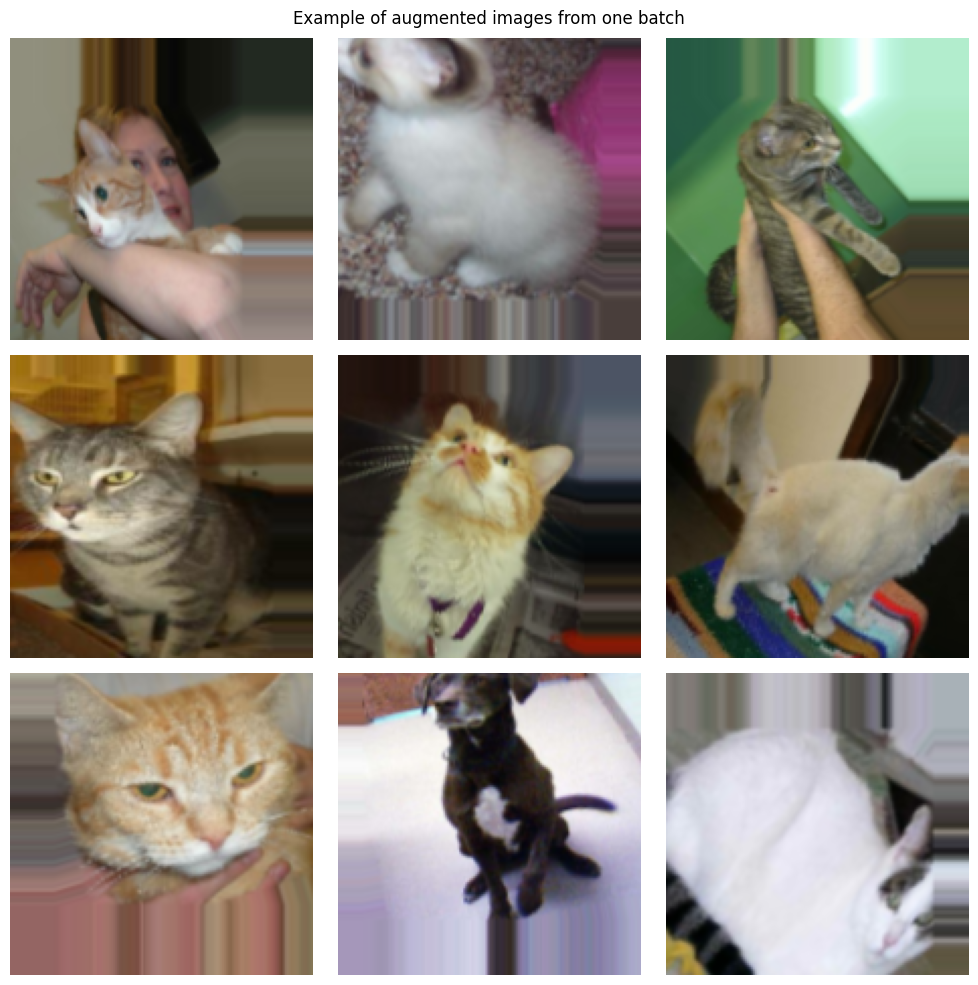

In [6]:
for images, labels in train_dataset.take(1):
    plt.figure(figsize=(10, 10))
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        augmented_images = data_augmentation(images, training=True)
        plt.imshow(augmented_images[i])
        plt.axis("off")
    plt.suptitle("Example of augmented images from one batch")
    plt.tight_layout()
    plt.show()

## Fit the Model

In [7]:
history = network.fit(train_dataset, epochs=30, validation_data=val_dataset)

Epoch 1/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 31s 300ms/step - accuracy: 0.5080 - loss: 0.6948 - val_accuracy: 0.4680 - val_loss: 0.6935
Epoch 2/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 31s 300ms/step - accuracy: 0.5080 - loss: 0.6948 - val_accuracy: 0.4680 - val_loss: 0.6935
Epoch 2/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 19s 186ms/step - accuracy: 0.4970 - loss: 0.6939 - val_accuracy: 0.5220 - val_loss: 0.6895
Epoch 3/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 19s 186ms/step - accuracy: 0.4970 - loss: 0.6939 - val_accuracy: 0.5220 - val_loss: 0.6895
Epoch 3/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 16s 162ms/step - accuracy: 0.5195 - loss: 0.6923 - val_accuracy: 0.5620 - val_loss: 0.6886
Epoch 4/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 17s 167ms/step - accuracy: 0.5390 - loss: 0.6885 - val_accuracy: 0.5360 - val_loss: 0.6843
Epoch 5/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 15s 152ms/step - accuracy: 0.5525 - loss: 0.6839 - val_accuracy: 0.5710 - val_loss: 0.6665
Epoch 6/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 16s 163ms/step - accuracy: 0.5800 - loss: 0

## Outcome Analysis

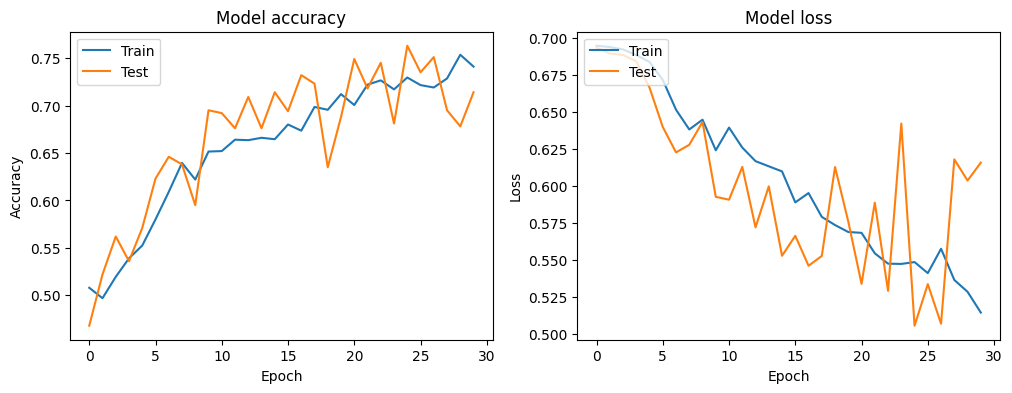

In [8]:
# plot training & validation accuracy values
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')

# plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')

plt.show()

# Part 2 Adding Dropout Layer [[lab2b](https://mdig.agh.edu.pl/dokuwiki/doku.php?id=teaching:data_science:dnn:lab2b#part_2_adding_dropout_layer)]

In [9]:
network = models.Sequential()
network.add(layers.Input(shape=(150, 150, 3)))
network.add(data_augmentation)
network.add(layers.Conv2D(32, (3, 3), activation="relu"))
network.add(layers.MaxPooling2D((2, 2)))
network.add(layers.Conv2D(64, (3, 3), activation="relu"))
network.add(layers.MaxPooling2D((2, 2)))
network.add(layers.Conv2D(128, (3, 3), activation="relu"))
network.add(layers.MaxPooling2D((2, 2)))
network.add(layers.Conv2D(128, (3, 3), activation="relu"))
network.add(layers.MaxPooling2D((2, 2)))
network.add(layers.Flatten())
network.add(layers.Dropout(0.5))  # new dropout layer
network.add(layers.Dense(512, activation="relu"))
network.add(layers.Dense(1, activation="sigmoid"))

network.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 15, 15, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │     3,211,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,453,121 (13.17 MB)

 Trainable params: 3,453,121 (13.17 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
network.compile(optimizer="rmsprop", loss="binary_crossentropy", metrics=["accuracy"])

In [11]:
history = network.fit(train_dataset, epochs=30, validation_data=val_dataset)

Epoch 1/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 16s 151ms/step - accuracy: 0.5020 - loss: 0.7007 - val_accuracy: 0.4790 - val_loss: 0.6928
Epoch 2/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 15s 155ms/step - accuracy: 0.5050 - loss: 0.6936 - val_accuracy: 0.5340 - val_loss: 0.7196
Epoch 3/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 16s 158ms/step - accuracy: 0.5365 - loss: 0.6913 - val_accuracy: 0.5920 - val_loss: 0.6750
Epoch 4/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 16s 160ms/step - accuracy: 0.5545 - loss: 0.6848 - val_accuracy: 0.5240 - val_loss: 0.8123
Epoch 5/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 16s 163ms/step - accuracy: 0.5695 - loss: 0.6842 - val_accuracy: 0.6210 - val_loss: 0.6527
Epoch 6/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 16s 163ms/step - accuracy: 0.6065 - loss: 0.6630 - val_accuracy: 0.5920 - val_loss: 0.6476
Epoch 7/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 16s 159ms/step - accuracy: 0.6170 - loss: 0.6566 - val_accuracy: 0.6580 - val_loss: 0.6435
Epoch 8/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 16s 161ms/step - accuracy: 0.6400 - loss: 0

## Outcome Analysis

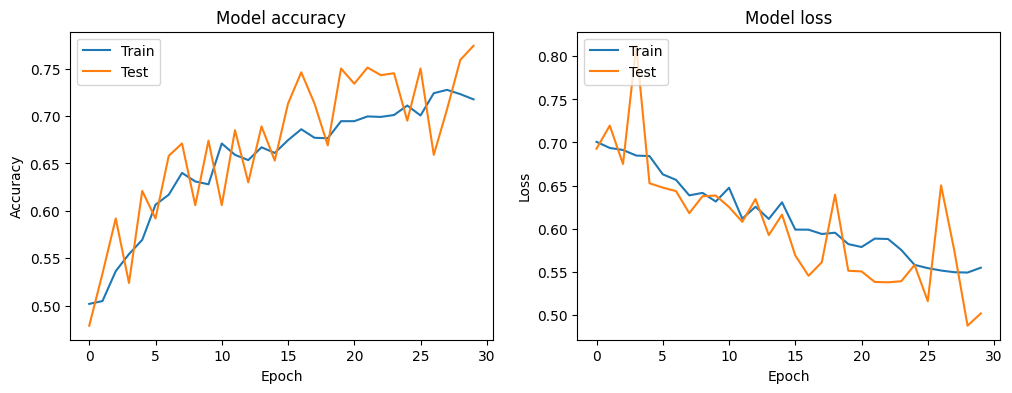

In [12]:
# plot training & validation accuracy values
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')

plt.legend(['Train', 'Test'], loc='upper left')

# plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')

plt.show()